In [ ]:
# ==========================================================
# ULTRA-FAST HIGH-ACCURACY LIGHTGBM (< 3 MINUTE RUNTIME)
# train.csv + test.csv + sample_submission.csv
# ==========================================================

# ============================
# 1. Import Libraries
# ============================
import pandas as pd
# import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import accuracy_score

# Machine Learning & Preprocessing
# from sklearn.model_selection import StratifiedKFold
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import roc_auc_score
# import lightgbm as lgb

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# Set aesthetic styling for plots
sns.set_theme(style="whitegrid", palette="muted")

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# ============================
# 2. Load Data
# ============================

KAGGLE_DATASET_URL = "/kaggle/input/competitions/playground-series-s6e9/"

def find_data_dir() -> Path:
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.extend([
        cwd,
        cwd / "notebook",
        cwd.parent,
        cwd.parent / "notebook",
    ])

    for base in candidates:
        for candidate in [base / "input", base.parent / "input"]:
            if candidate.exists() and (candidate / "train.csv").exists() and (candidate / "test.csv").exists():
                return candidate

    for kaggle_path in [
        Path(KAGGLE_DATASET_URL),
        Path("/kaggle/input/train.csv").parent,
    ]:
        if kaggle_path.exists() and (kaggle_path / "train.csv").exists() and (kaggle_path / "test.csv").exists():
            return kaggle_path

    return Path(KAGGLE_DATASET_URL)


data_dir = find_data_dir()

train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")
sample_submission = pd.read_csv(data_dir / "sample_submission.csv")

# ============================
# 3. Separate X and y
# ============================
TARGET = "Will_Buy_EV"
X = train.drop(columns=[TARGET])
y = train[TARGET]
X_test = test.copy()


In [3]:
# ==========================================================
# IMPORTS
# ==========================================================
import warnings
warnings.filterwarnings("ignore")

import os
import gc
import random
import numpy as np
import pandas as pd

from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    log_loss,
)

from sklearn.preprocessing import LabelEncoder

# LightGBM
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("="*60)
print("Environment Ready")
print("="*60)

Environment Ready


In [4]:
# ==========================================================
# LOAD DATA
# ==========================================================

TARGET = "Will_Buy_EV"

#train = pd.read_csv("train.csv")
#test = pd.read_csv("test.csv")
#sample_submission = pd.read_csv("sample_submission.csv")

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

display(train.head())

Train Shape : (668665, 15)
Test Shape  : (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [5]:
# ==========================================================
# DATASET SUMMARY
# ==========================================================

print("\nTrain Info")
display(train.info())

print("\nMissing Values")
display(train.isnull().sum().sort_values(ascending=False).head(30))

print("\nData Types")
display(train.dtypes.value_counts())

print("\nDuplicate Rows :", train.duplicated().sum())


Train Info
<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13

None


Missing Values


id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64


Data Types


str        7
int64      5
float64    3
Name: count, dtype: int64


Duplicate Rows : 0


In [6]:
# ==========================================================
# BASIC CLEANING
# ==========================================================

# Remove duplicate rows from training only
before = train.shape[0]
train = train.drop_duplicates().reset_index(drop=True)
after = train.shape[0]

print(f"Removed {before-after} duplicate rows")

# Separate target
y = train[TARGET].copy()

train_features = train.drop(columns=[TARGET])
test_features = test.copy()

# Remove constant columns
constant_cols = [
    c for c in train_features.columns
    if train_features[c].nunique(dropna=False) <= 1
]

if len(constant_cols) > 0:
    print("Removing constant columns:")
    print(constant_cols)

    train_features.drop(columns=constant_cols, inplace=True)
    test_features.drop(columns=constant_cols, inplace=True)

print("Train Shape:", train_features.shape)
print("Test Shape :", test_features.shape)

Removed 0 duplicate rows
Train Shape: (668665, 14)
Test Shape : (286571, 14)


In [7]:
# ==========================================================
# FEATURE DETECTION
# ==========================================================

numeric_cols = train_features.select_dtypes(
    include=["int8","int16","int32","int64",
             "float16","float32","float64"]
).columns.tolist()

object_cols = train_features.select_dtypes(
    include=["object"]
).columns.tolist()

category_cols = train_features.select_dtypes(
    include=["category"]
).columns.tolist()

bool_cols = train_features.select_dtypes(
    include=["bool"]
).columns.tolist()

datetime_cols = []

for col in object_cols:
    try:
        converted = pd.to_datetime(train_features[col], errors="coerce")

        if converted.notna().mean() > 0.80:
            datetime_cols.append(col)
    except:
        pass

print("="*60)
print("Numeric :", len(numeric_cols))
print("Object  :", len(object_cols))
print("Category:", len(category_cols))
print("Boolean :", len(bool_cols))
print("Datetime:", len(datetime_cols))
print("="*60)

Numeric : 8
Object  : 6
Category: 0
Boolean : 0
Datetime: 0


In [8]:
# ==========================================================
# DATETIME FEATURES
# ==========================================================

for col in datetime_cols:

    train_features[col] = pd.to_datetime(
        train_features[col],
        errors="coerce"
    )

    test_features[col] = pd.to_datetime(
        test_features[col],
        errors="coerce"
    )

    for df in [train_features, test_features]:

        df[col+"_year"] = df[col].dt.year
        df[col+"_month"] = df[col].dt.month
        df[col+"_day"] = df[col].dt.day
        df[col+"_dayofweek"] = df[col].dt.dayofweek
        df[col+"_week"] = df[col].dt.isocalendar().week.astype("float")
        df[col+"_quarter"] = df[col].dt.quarter

    train_features.drop(columns=[col], inplace=True)
    test_features.drop(columns=[col], inplace=True)

print("Datetime engineering completed.")

Datetime engineering completed.


In [9]:
# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

# Numeric columns
num_cols = train_features.select_dtypes(include=np.number).columns

for col in num_cols:

    median = train_features[col].median()

    train_features[col] = train_features[col].fillna(median)
    test_features[col] = test_features[col].fillna(median)

# Object columns
obj_cols = train_features.select_dtypes(include=["object"]).columns

for col in obj_cols:

    train_features[col] = train_features[col].fillna("Missing")
    test_features[col] = test_features[col].fillna("Missing")

print("Missing values handled.")

Missing values handled.


In [10]:
# ==========================================================
# LABEL ENCODING
# ==========================================================

obj_cols = train_features.select_dtypes(include=["object"]).columns

encoders = {}

for col in obj_cols:

    le = LabelEncoder()

    values = pd.concat([
        train_features[col],
        test_features[col]
    ], axis=0).astype(str)

    le.fit(values)

    train_features[col] = le.transform(train_features[col].astype(str))
    test_features[col] = le.transform(test_features[col].astype(str))

    encoders[col] = le

print(f"Encoded {len(obj_cols)} categorical columns.")

Encoded 6 categorical columns.


In [11]:
# ==========================================================
# MEMORY OPTIMIZATION
# ==========================================================

def reduce_memory(df):

    start = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:

        col_type = df[col].dtype

        if str(col_type).startswith("int"):

            c_min = df[col].min()
            c_max = df[col].max()

            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)

            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)

            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)

        elif str(col_type).startswith("float"):

            c_min = df[col].min()
            c_max = df[col].max()

            if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)

    end = df.memory_usage(deep=True).sum() / 1024**2

    print(f"Memory: {start:.2f} MB -> {end:.2f} MB")

    return df


train_features = reduce_memory(train_features)
test_features = reduce_memory(test_features)

Memory: 71.42 MB -> 16.58 MB
Memory: 30.61 MB -> 7.11 MB


In [12]:
# ==========================================================
# REMOVE ID-LIKE FEATURES
# ==========================================================

remove_cols = []

for col in train_features.columns:

    # Same as row count → almost certainly an ID
    if train_features[col].nunique() == len(train_features):

        if "id" in col.lower():

            remove_cols.append(col)

if remove_cols:

    print("Removing ID columns:")
    print(remove_cols)

    train_features.drop(columns=remove_cols, inplace=True)
    test_features.drop(columns=remove_cols, inplace=True)

else:
    print("No obvious ID columns found.")

Removing ID columns:
['id']


Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64


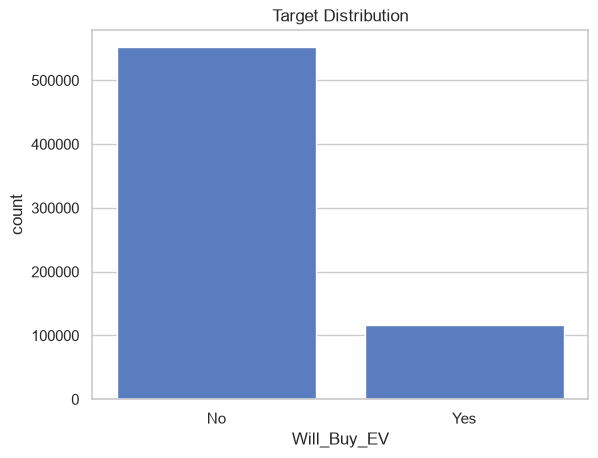

In [13]:
# ==========================================================
# TARGET DISTRIBUTION
# ==========================================================

print(y.value_counts())

print()

print(
    y.value_counts(normalize=True)
)

sns.countplot(x=y)

plt.title("Target Distribution")

plt.show()

In [14]:
# ==========================================================
# LIGHTGBM PARAMETERS
# ==========================================================

lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.02,
    "n_estimators": 2000,
    "num_leaves": 63,
    "max_depth": -1,
    "subsample": 0.80,
    "subsample_freq": 1,
    "colsample_bytree": 0.80,
    "min_child_samples": 20,
    "reg_alpha": 0.10,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "force_col_wise": True
}

In [15]:
# ==========================================================
# LIGHTGBM - 10 FOLD STRATIFIED CV
# ==========================================================

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

N_SPLITS = 10

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

oof_pred = np.zeros(len(train_features))
test_pred = np.zeros(len(test_features))

feature_importance = pd.DataFrame()

scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(train_features, y), 1):

    print("=" * 70)
    print(f"Fold {fold}/{N_SPLITS}")
    print("=" * 70)

    X_train = train_features.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = train_features.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    model = LGBMClassifier(**lgb_params)

    model.fit(
        X_train,
        y_train,

        eval_set=[
            (X_valid, y_valid)
        ],

        eval_metric="auc",

        callbacks=[
            early_stopping(200),
            log_evaluation(200)
        ]
    )

    valid_pred = model.predict_proba(
        X_valid,
        num_iteration=model.best_iteration_
    )[:,1]

    oof_pred[valid_idx] = valid_pred

    fold_auc = roc_auc_score(y_valid, valid_pred)

    scores.append(fold_auc)

    print(f"Fold {fold} AUC : {fold_auc:.6f}")

    test_pred += model.predict_proba(
        test_features,
        num_iteration=model.best_iteration_
    )[:,1] / N_SPLITS

    fold_importance = pd.DataFrame({
        "feature": train_features.columns,
        "importance": model.feature_importances_,
        "fold": fold
    })

    feature_importance = pd.concat(
        [feature_importance, fold_importance],
        axis=0
    )

    del model
    gc.collect()

print("\n")

print("=" * 70)
print("CV Finished")
print("=" * 70)

print("Fold Scores")

for i, score in enumerate(scores):
    print(f"Fold {i+1}: {score:.6f}")

print()

print("Mean AUC :", np.mean(scores))
print("Std AUC  :", np.std(scores))

print()

print("Overall OOF AUC :", roc_auc_score(y, oof_pred))

Fold 1/10
[LightGBM] [Info] Number of positive: 105101, number of negative: 496697
[LightGBM] [Info] Total Bins 619
[LightGBM] [Info] Number of data points in the train set: 601798, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553058
[LightGBM] [Info] Start training from score -1.553058
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.939761
[400]	valid_0's auc: 0.940249
[600]	valid_0's auc: 0.940455
[800]	valid_0's auc: 0.940545
[1000]	valid_0's auc: 0.940557
Early stopping, best iteration is:
[962]	valid_0's auc: 0.940569
Fold 1 AUC : 0.940569
Fold 2/10
[LightGBM] [Info] Number of positive: 105101, number of negative: 496697
[LightGBM] [Info] Total Bins 619
[LightGBM] [Info] Number of data points in the train set: 601798, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553058
[LightGBM] [Info] Start training from score -1.553058
Training unt

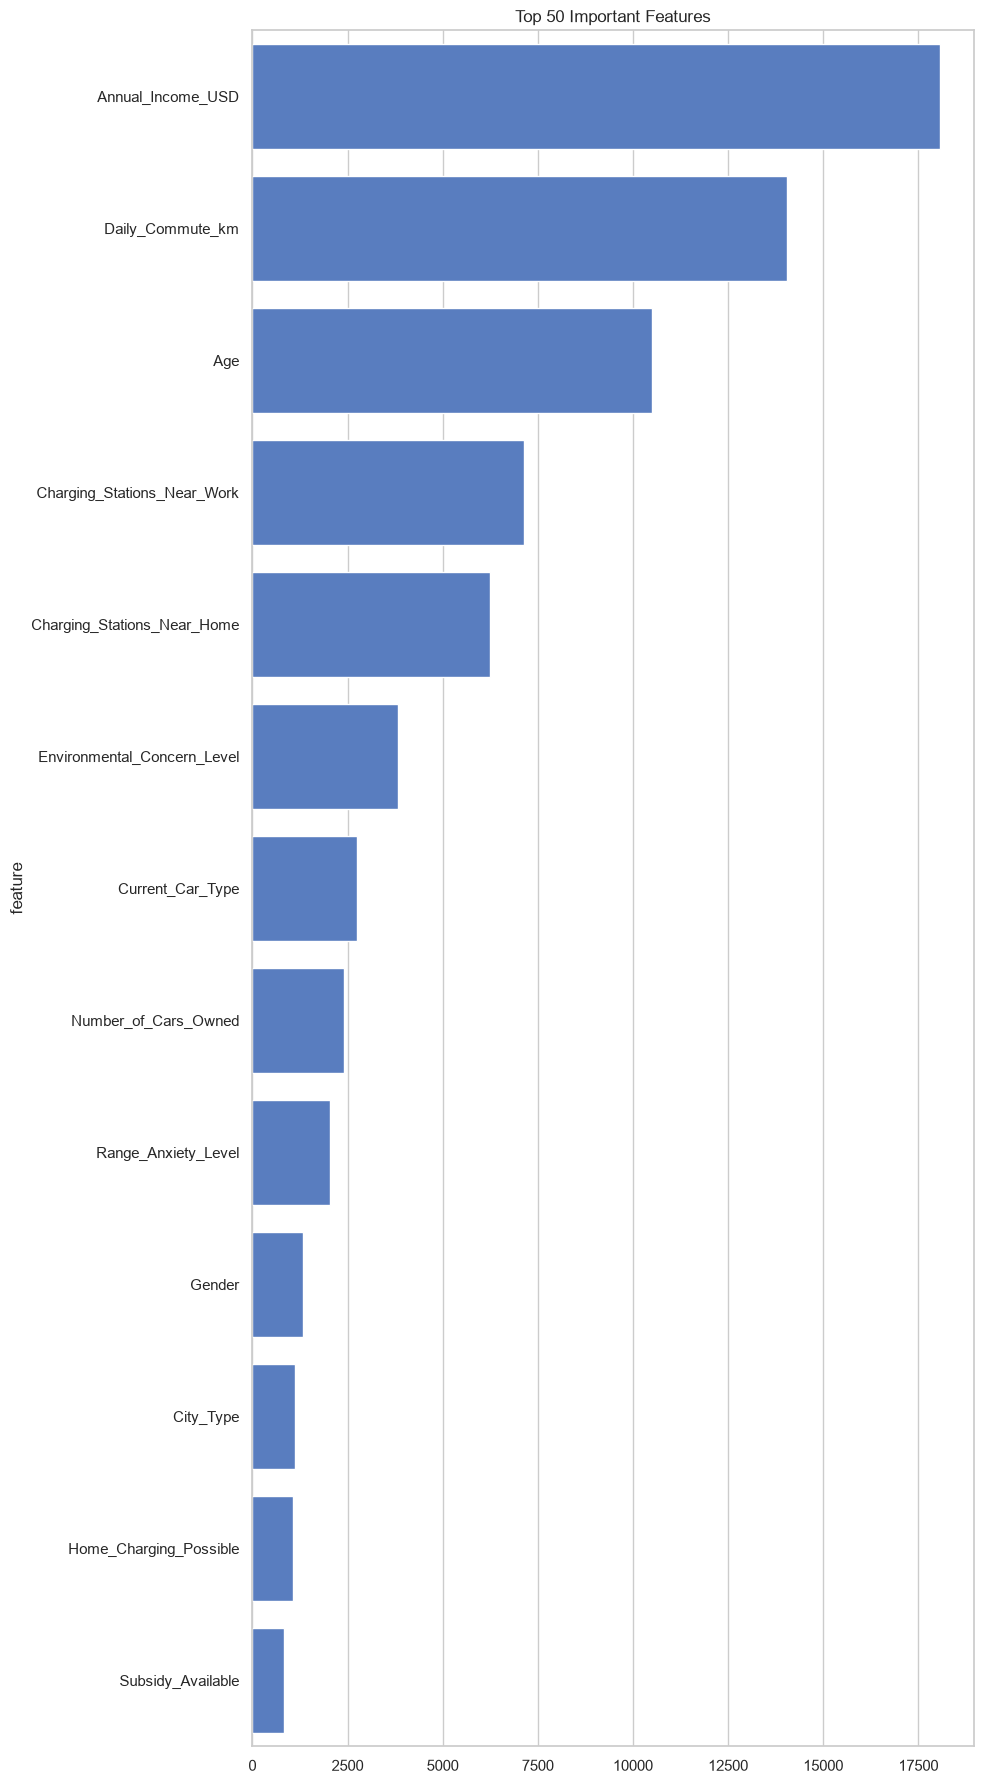

feature
Annual_Income_USD              18058.7
Daily_Commute_km               14047.3
Age                            10505.1
Charging_Stations_Near_Work     7136.4
Charging_Stations_Near_Home     6256.4
Environmental_Concern_Level     3827.3
Current_Car_Type                2746.6
Number_of_Cars_Owned            2416.0
Range_Anxiety_Level             2051.6
Gender                          1342.0
City_Type                       1131.8
Home_Charging_Possible          1071.9
Subsidy_Available                839.1
Name: importance, dtype: float64

In [16]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = (
    feature_importance
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,18))

sns.barplot(
    x=importance.values[:50],
    y=importance.index[:50],
    orient="h"
)

plt.title("Top 50 Important Features")

plt.tight_layout()

plt.show()

importance.head(50)

In [17]:
# ==========================================================
# SUBMISSION
# ==========================================================

sample_submission[TARGET] = test_pred
sample_submission.to_parquet("submission.parquet",index=False)
print(sample_submission.head())
print()
print("Submission saved successfully.")

       id  Will_Buy_EV
0  668665     0.010137
1  668666     0.016442
2  668667     0.004977
3  668668     0.002918
4  668669     0.018262

Submission saved successfully.
